In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

In [2]:
import torch.optim as optim
from torch.utils.data import DataLoader

In [3]:
import matplotlib.pyplot as plt

In [4]:
train_dataset = datasets.MNIST(root='MnistData', train=True, transform=transforms.ToTensor(), download=True)

In [5]:
test_dataset = datasets.MNIST(root='MnistData', train=False, transform=transforms.ToTensor(), download=True)    

In [9]:
train_dataset[23]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [8]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

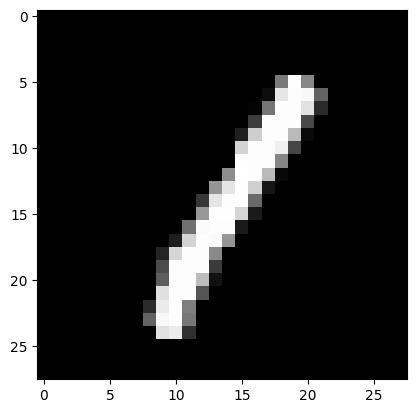

In [10]:
plt.imshow(train_dataset.data[23], cmap='gray')

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [20]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.model(x)

In [ ]:
modelMLP = MLP()

In [22]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(modelMLP.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):
    for images, labels in train_loader:
        outputs = modelMLP(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("loss:",loss.item())

loss: 0.15261387825012207
loss: 0.1645086109638214
loss: 0.12385743111371994
loss: 0.0468083880841732
loss: 0.03320921212434769


In [ ]:
modelMLP.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = modelMLP(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print("Test accuracy:", accuracy)

Test accuracy: 0.975


In [42]:
image,label=test_dataset[0]

True label: 7


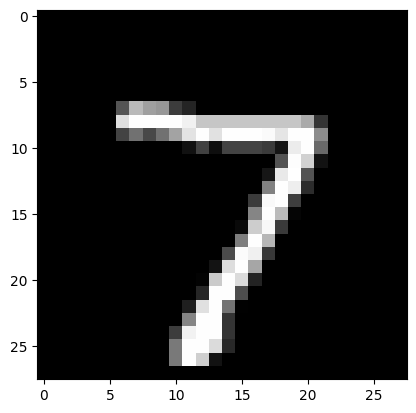

In [47]:
plt.imshow(image.squeeze(), cmap='gray') #squeeze() removes the extra dimension from the image tensor, making it compatible with imshow for display.
print("True label:", label)

In [31]:
def predict(model, image):
    model.eval()
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)
    return predicted.item()

In [ ]:
predict(modelMLP, image)

7

MLP (Multi-Layer Perceptron): To an MLP, an image is just a long list of numbers. It flattens the 28x28 grid into a single vector of 784 pixels. It doesn't know that pixel #1 is right above pixel #29; it treats them as independent features.
MLP: It relies on "Global" features. Every input neuron is connected to every neuron in the next layer. It tries to find patterns across the entire image at once. If you shift the digit "3" just a few pixels to the left, an MLP might fail because the "3" is no longer where it expected the pixels to be.

CNN (Convolutional Neural Network): A CNN keeps the image in its 2D shape. It uses "filters" (small kernels) that slide across the image to look for patterns. This allows it to understand spatial relationships—like how a horizontal line and a vertical line meet to form a corner.
CNN: It uses Translation Invariance. Because the filters slide across the whole image, a CNN can recognize a "loop" or a "cross" regardless of where it appears in the frame. This makes it much more robust.

The MLP is like a student memorizing exactly where every dot is on a page. If the page moves slightly, they get confused.

The CNN is like a student learning what a "circle" and a "line" look like. No matter where those shapes appear on the page, the student can identify them.

## CNN


In [16]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.model(x)

we start with [64, 1, 28, 28]
a batch of 64 images each 1 Channel 28*28

``` nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=1) ```
| Parameter     | Meaning                         |
| ------------- | ------------------------------- |
| 1             | input channel (grayscale image) |
| 32            | number of filters               |
| kernel_size=5 | 5×5 filter                      |
| stride=1      | move 1 pixel each step          |
| padding=1     | add border pixels               |

The CNN learns 32 different feature detectors such as:

* edges
* curves
* stroke patterns
* corners

Size calculation

Output size formula:

$$(𝑊−𝐾+2𝑃)/𝑆+1$$

Here:

W = 28

K = 5

P = 1

S = 1

$$(28−5+2)/1+1=26$$

then we get [batch, 32, 26, 26]
batch of 64 images each 32 Channels of 26*26

``` nn.MaxPool2d(kernel_size=2, stride=2) ```
Pooling reduces spatial size.
For each 2×2 block, it keeps the maximum value.

[batch, 32, 13, 13]
reduced size to 13*13

``` nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=1) ```

Now the network detects more complex features.

Instead of simple edges, it might detect:
* digit curves
* stroke intersections
* shapes of numbers

Channels increase: 32 → 64 feature maps

[batch, 64, 11, 11]


Second Max Pooling
nn.MaxPool2d(kernel_size=2, stride=2)
[batch, 64, 5, 5]


Input image 

```[1,28,28] ```

Conv1
[32,26,26]

MaxPool
[32,13,13]

Conv2
[64,11,11]

MaxPool
[64,5,5]

Flatten
[1600]

Linear
[128]

Output
[10]


In [17]:
modelCNN = CNN()

In [26]:
optimizerCNN = optim.Adam(modelCNN.parameters(), lr=0.001)

In [27]:
for epoch in range(5):
    for images, labels in train_loader:
        outputs = modelCNN(images)
        loss = criterion(outputs, labels)

        optimizerCNN.zero_grad()
        loss.backward()
        optimizerCNN.step()
    print("loss:",loss.item())

loss: 0.009256486780941486
loss: 0.008420975878834724
loss: 0.11139404773712158
loss: 0.09084415435791016
loss: 0.00017457560170441866


In [ ]:
modelCNN.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = modelCNN(images)

        _, predicted = torch.max(outputs, 1) #(values, indices)

        total += labels.size(0)
        correct += (predicted == labels).sum().item() #[True, False, True, True] counts the number of True .item() converts the tensor into a Python number.

In [29]:
accuracy = correct / total
print("Test accuracy:", accuracy*100, "%")

Test accuracy: 99.2 %


In [30]:
torch.save(modelCNN.state_dict(), "cnn_mnist.pth")

to load parameters without the need to retrain

In [ ]:
modelCNN.load_state_dict(torch.load("cnn_mnist.pth")) 

In [48]:
image2,label2=test_dataset[888]

True label: 2


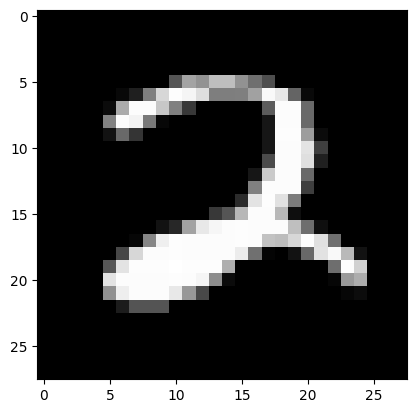

In [49]:
plt.imshow(image2.squeeze(), cmap='gray')
print("True label:", label2)

In [50]:
predict(modelCNN, image2)

2

When you do:

image, label = test_dataset[i]

Internally:

MNIST retrieves the raw data:

img = self.data[i]      # raw 28x28 tensor

target = self.targets[i]  # label


Converts the image to a PIL Image:

img = PIL.Image.fromarray(img.numpy())


Applies your transform if you provided one:

if self.transform:
    img = self.transform(img)   # e.g., ToTensor(), Normalize()